# Cluster visualization for TSFM outputs
This notebook loads embeddings and predictions produced by `TSFM.py` (saved in `outputs/`) and provides an interactive workflow to inspect clusters, visualize representative time series, and save results for downstream analysis.

Run the cells in order. If you don't have many embeddings yet (e.g. only 1 sample), clustering won't be meaningful — consider running `TSFM.py` over your full dataset to populate `outputs/` first.

In [11]:
# Section 1: imports and plotting config
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.metrics import silhouette_score, davies_bouldin_score
import time

# optional imports (tsne, umap)
try:
    from sklearn.manifold import TSNE
except Exception:
    TSNE = None
try:
    import umap.umap_ as umap
except Exception:
    umap = None

np.random.seed(0)
sns.set_style('whitegrid')
OUT_DIR = 'outputs'
FIG_DIR = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
print('Ready. Figures will be saved to', FIG_DIR)

Ready. Figures will be saved to outputs/figures


In [12]:
# Section 2: safe loaders for saved artifacts
import json

def safe_load_npy(path):
    if not os.path.exists(path):
        # print(f'File not found: {path}')
        return None
    try:
        return np.load(path, allow_pickle=True)
    except Exception as e:
        print('Failed to load', path, e)
        return None


def load_hrv_features(out_dir=OUT_DIR):
    feat_path = os.path.join(out_dir, 'hrv_features.npy')
    names_path = os.path.join(out_dir, 'hrv_feature_names.json')
    feats = None
    names = None
    if os.path.exists(feat_path):
        try:
            feats = np.load(feat_path, allow_pickle=True)
        except Exception as e:
            print('Failed to load HRV features:', e)
    if os.path.exists(names_path):
        try:
            with open(names_path, 'r') as f:
                names = json.load(f)
        except Exception:
            names = None
    return feats, names


def load_artifacts(out_dir=OUT_DIR):
    # Prefer combined embeddings with HRV if available
    emb_candidates = [
        os.path.join(out_dir, 'embeddings_with_hrv.npy'),
        os.path.join(out_dir, 'embeddings_all.npy'),
        os.path.join(out_dir, 'embeddings.npy')
    ]
    emb = None
    for p in emb_candidates:
        if os.path.exists(p):
            try:
                emb = np.load(p, allow_pickle=True)
                print('Loaded embeddings from', p)
                break
            except Exception as e:
                print('Failed to load', p, e)
    preds = safe_load_npy(os.path.join(out_dir, 'preds.npy'))
    hidden = safe_load_npy(os.path.join(out_dir, 'hidden_raw.npy'))
    return emb, preds, hidden


In [13]:
# Section 3: load and inspect artifacts
emb, preds, hidden = load_artifacts()
print('embeddings:', None if emb is None else emb.shape)
print('preds:', None if preds is None else preds.shape)
print('hidden raw:', None if hidden is None else getattr(hidden, 'shape', 'object'))

# Quick sanity checks
def summary_array(a, name='a'):
    if a is None:
        print(name, 'is None')
        return
    a = np.asarray(a)
    print(f'{name}: shape={a.shape} dtype={a.dtype} min={np.nanmin(a):.3f} max={np.nanmax(a):.3f} mean={np.nanmean(a):.3f}')
    print('  n_nan=', np.isnan(a).sum(), 'n_inf=', np.isinf(a).sum())

summary_array(emb, 'emb')
summary_array(preds, 'preds')

Loaded embeddings from outputs/embeddings_with_hrv.npy
embeddings: (2290, 135)
preds: (2290, 96, 1)
hidden raw: (3, 1, 1, 43, 128)
emb: shape=(2290, 135) dtype=float64 min=-0.125 max=0.155 mean=0.013
  n_nan= 13740 n_inf= 0
preds: shape=(2290, 96, 1) dtype=float32 min=nan max=nan mean=nan
  n_nan= 219840 n_inf= 0


/var/folders/js/0r3rgb8104s7jnth94r86nd00000gn/T/ipykernel_54885/996926751.py:13: RuntimeWarning: All-NaN slice encountered
  print(f'{name}: shape={a.shape} dtype={a.dtype} min={np.nanmin(a):.3f} max={np.nanmax(a):.3f} mean={np.nanmean(a):.3f}')
/var/folders/js/0r3rgb8104s7jnth94r86nd00000gn/T/ipykernel_54885/996926751.py:13: RuntimeWarning: Mean of empty slice
  print(f'{name}: shape={a.shape} dtype={a.dtype} min={np.nanmin(a):.3f} max={np.nanmax(a):.3f} mean={np.nanmean(a):.3f}')


In [14]:
# Section 4: regenerate windows from the CSV to map embeddings back to series (if needed)
from Data_TSFM import load_csv, extract_series, normalize, create_sliding_windows
CSV_PATH = 'data/com.samsung.health.hrv.20251122092438.csv'
df = None
if os.path.exists(CSV_PATH):
    df = load_csv(CSV_PATH)
    series = extract_series(df, 'binning_data')
    series_norm, mean, std = normalize(series)
    LOOKBACK = 96
    HORIZON = 24
    windows = create_sliding_windows(series_norm, lookback=LOOKBACK, horizon=HORIZON)
    print('Loaded CSV and created windows: ', windows.shape)
else:
    print('CSV not found at', CSV_PATH, '— cannot regenerate windows')

# If embeddings are missing but preds exist, form embeddings by collapsing preds (mean over horizon/channels)
if emb is None and preds is not None:
    p = np.asarray(preds)
    if p.ndim == 3:
        emb = p.mean(axis=1)
    elif p.ndim == 2:
        emb = p
    print('Formed embeddings from preds, shape=', None if emb is None else emb.shape)

Loaded CSV and created windows:  (2290, 96)


In [15]:
# Section 5: preprocess embeddings (scaling + optional PCA denoise)
if emb is None:
    raise SystemExit('No embeddings available. Run TSFM over more windows or check outputs/embeddings.npy')

emb = np.asarray(emb)
print('emb raw shape', emb.shape)
if emb.size == 0:
    raise SystemExit('Embeddings array is empty (size=0). Check outputs/embeddings.npy and hidden_raw.npy')

# ensure 2D
if emb.ndim == 1:
    emb = emb.reshape(1, -1)

# If there are zero features, stop with a clear message
if emb.shape[1] == 0:
    raise SystemExit(f'Embeddings have zero features (shape={emb.shape}). This can happen if hidden states collapsed to an empty feature axis. Inspect outputs/embeddings.npy and outputs/hidden_raw.npy')

# Check for NaNs/Infs and handle them before PCA
n_nan = np.isnan(emb).sum()
n_inf = np.isinf(emb).sum()
print(f'Found n_nan={n_nan}, n_inf={n_inf}')
if n_nan > 0 or n_inf > 0:
    # Prefer imputation when scikit-learn is available
    try:
        from sklearn.impute import SimpleImputer
        imputer = SimpleImputer(strategy='mean')
        emb = imputer.fit_transform(emb)
        print('Imputed missing values with SimpleImputer(strategy="mean")')
    except Exception as e:
        print('SimpleImputer not available or failed:', e)
        # Fallback: drop rows with NaN/Inf
        mask = np.isfinite(emb).all(axis=1)
        dropped = (~mask).sum()
        emb = emb[mask]
        print(f'Dropped {dropped} samples with NaN/Inf. Remaining samples: {emb.shape[0]}')
        if emb.shape[0] == 0:
            raise SystemExit('All samples were dropped due to NaN/Inf. Cannot continue.')

# Continue with scaling
scaler = StandardScaler()
emb_scaled = scaler.fit_transform(emb)
print('emb_scaled shape', emb_scaled.shape)
# optional PCA denoising (keep at most 64 components or feature dim and respect sample count)
max_components = min(emb_scaled.shape[1], emb_scaled.shape[0], 64)
if max_components <= 0:
    raise SystemExit(f'Cannot run PCA because computed max_components={max_components} for emb_scaled.shape={emb_scaled.shape}')

pca_denoise = PCA(n_components=max_components)
emb_pca = pca_denoise.fit_transform(emb_scaled)
print('emb_pca shape', emb_pca.shape)
# save preprocessed
np.save(os.path.join(OUT_DIR, 'emb_preprocessed.npy'), emb_pca)
print('Saved emb_preprocessed.npy')

emb raw shape (2290, 135)
Found n_nan=13740, n_inf=0
Imputed missing values with SimpleImputer(strategy="mean")
emb_scaled shape (2290, 129)
emb_pca shape (2290, 64)
Saved emb_preprocessed.npy


/Users/wonksss/Documents/LongevityHackathon/hugging-twins/venv/lib/python3.13/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: [128 129 130 131 132 133]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/Users/wonksss/Documents/LongevityHackathon/hugging-twins/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


In [16]:
# Section 6: dimensionality reduction for visualization (PCA + optional t-SNE / UMAP)
# emb_pca expected shape: (n_samples, n_components)
n_samples, n_features = emb_pca.shape
print(f'emb_pca shape: {emb_pca.shape}')

# Create a 2D embedding for plotting. Handle small-N edge cases gracefully.
if n_samples >= 2 and n_features >= 2:
    pca2 = PCA(n_components=2)
    emb_2d = pca2.fit_transform(emb_pca)
elif n_samples >= 2 and n_features == 1:
    # Add a zero column to make 2D for plotting
    emb_2d = np.hstack([emb_pca, np.zeros((n_samples, 1))])
else:
    # n_samples == 1 (or zero, but zero should have been caught earlier)
    print('Warning: less than 2 samples available. Creating a 2D coordinate by padding/truncating the single embedding.')
    if n_features >= 2:
        emb_2d = emb_pca[:, :2]
    elif n_features == 1:
        emb_2d = np.array([[emb_pca[0, 0], 0.0]])
    else:
        emb_2d = np.zeros((1, 2))

print('emb_2d shape', emb_2d.shape)

# t-SNE (optional, can be slow) — only run when there are enough samples
if TSNE is not None and emb_pca.shape[0] > 2 and emb_pca.shape[0] < 2000:
    t0 = time.time()
    emb_tsne = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(emb_pca)
    print('t-SNE done in', time.time()-t0, 's')
else:
    emb_tsne = None

# UMAP (optional) — only run when there are enough samples
if umap is not None and emb_pca.shape[0] > 2:
    emb_umap = umap.UMAP(n_components=2, random_state=0).fit_transform(emb_pca)
else:
    emb_umap = None

# save reduced coords
np.save(os.path.join(OUT_DIR, 'emb_2d_pca.npy'), emb_2d)
if emb_tsne is not None:
    np.save(os.path.join(OUT_DIR, 'emb_tsne.npy'), emb_tsne)
if emb_umap is not None:
    np.save(os.path.join(OUT_DIR, 'emb_umap.npy'), emb_umap)
print('Saved reduced coordinates')

emb_pca shape: (2290, 64)
emb_2d shape (2290, 2)


/Users/wonksss/Documents/LongevityHackathon/hugging-twins/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/wonksss/Documents/LongevityHackathon/hugging-twins/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved reduced coordinates


In [17]:
# Section 7: clustering — KMeans and DBSCAN, silhouette scan for k selection
n_samples = emb_pca.shape[0]
print('n_samples for clustering:', n_samples)

def run_kmeans(emb, k=3):
    if emb.shape[0] < k:
        raise ValueError(f'n_samples={emb.shape[0]} < n_clusters={k}')
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(emb)
    return labels, km


def scan_k(emb, ks=None):
    if ks is None:
        # limit max k to at most number of samples
        ks = list(range(2, min(8, emb.shape[0] + 1)))
    best = None
    scores = {}
    for k in ks:
        if emb.shape[0] < k:
            scores[k] = float('nan')
            continue
        try:
            labels, km = run_kmeans(emb, k=k)
            # silhouette requires at least 2 clusters and more samples than clusters
            score = silhouette_score(emb, labels) if (emb.shape[0] > 1 and len(np.unique(labels)) > 1) else float('nan')
        except Exception:
            score = float('nan')
        scores[k] = score
    return scores

# If too few samples, skip KMeans scan and assign a single cluster
if n_samples < 2:
    print('Not enough samples for KMeans clustering (need at least 2). Assigning single cluster label 0.')
    labels = np.zeros(n_samples, dtype=int)
    chosen_k = 1
    # save trivial labels
    np.save(os.path.join(OUT_DIR, f'cluster_labels_k{chosen_k}.npy'), labels)
    print('Saved trivial cluster labels')
else:
    scores = scan_k(emb_pca, ks=range(2,8))
    print('silhouette scores by k:', scores)
    # choose k with highest score (ignoring nan)
    valid = {k: v for k, v in scores.items() if not np.isnan(v)}
    chosen_k = max(valid, key=valid.get) if valid else 2
    print('Chosen k=', chosen_k)
    labels, km = run_kmeans(emb_pca, k=chosen_k)
    np.save(os.path.join(OUT_DIR, f'cluster_labels_k{chosen_k}.npy'), labels)
    print('Saved cluster labels')

# DBSCAN example — only run when there are enough samples
if n_samples >= 5:
    db = DBSCAN(eps=0.5, min_samples=5).fit(emb_pca)
    np.save(os.path.join(OUT_DIR, 'cluster_labels_dbscan.npy'), db.labels_)
    print('Saved DBSCAN labels')
else:
    print('Skipping DBSCAN: not enough samples (need at least 5)')

n_samples for clustering: 2290
silhouette scores by k: {2: nan, 3: nan, 4: nan, 5: nan, 6: nan, 7: nan}
Chosen k= 2
Saved cluster labels
Saved DBSCAN labels


/Users/wonksss/Documents/LongevityHackathon/hugging-twins/venv/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/wonksss/Documents/LongevityHackathon/hugging-twins/venv/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/wonksss/Documents/LongevityHackathon/hugging-twins/venv/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/wonksss/Documents/LongevityHackathon/hugging-twins/venv/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Nu

Saved outputs/figures/clusters_k2_pca.png
Saved outputs/figures/clusters_k2_umap.png


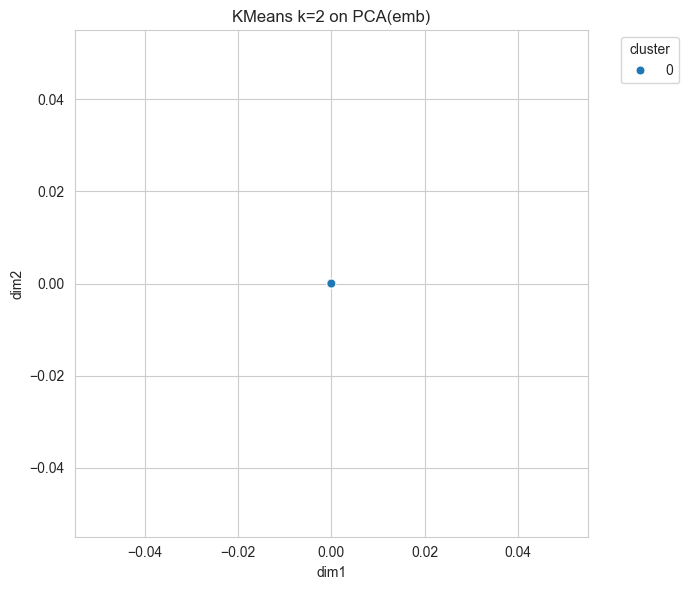

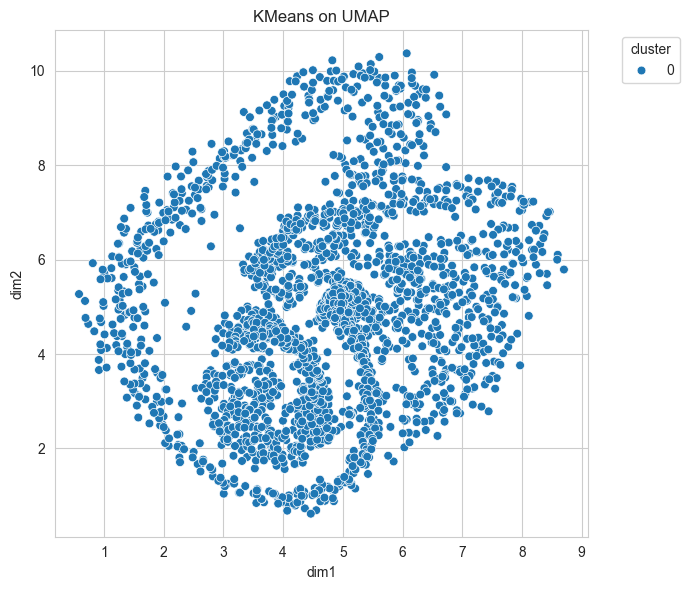

In [18]:
# Section 8: visualize clusters in 2D (PCA projection)
def plot_clusters(coords, labels, title, fname):
    fig, ax = plt.subplots(figsize=(7,6))
    palette = sns.color_palette('tab10', n_colors=len(np.unique(labels)))
    sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=labels, palette=palette, s=40, ax=ax, legend='brief')
    ax.set_title(title)
    ax.set_xlabel('dim1')
    ax.set_ylabel('dim2')
    ax.legend(title='cluster', bbox_to_anchor=(1.05,1), loc='upper left')
    fig.tight_layout()
    fig.savefig(fname)
    print('Saved', fname)

plot_clusters(emb_2d, labels, f'KMeans k={chosen_k} on PCA(emb)', os.path.join(FIG_DIR, f'clusters_k{chosen_k}_pca.png'))
# optional t-SNE/UMAP plots
if emb_tsne is not None:
    plot_clusters(emb_tsne, labels, 'KMeans on t-SNE', os.path.join(FIG_DIR, f'clusters_k{chosen_k}_tsne.png'))
if emb_umap is not None:
    plot_clusters(emb_umap, labels, 'KMeans on UMAP', os.path.join(FIG_DIR, f'clusters_k{chosen_k}_umap.png'))

Saved outputs/figures/cluster_2_0_examples.png


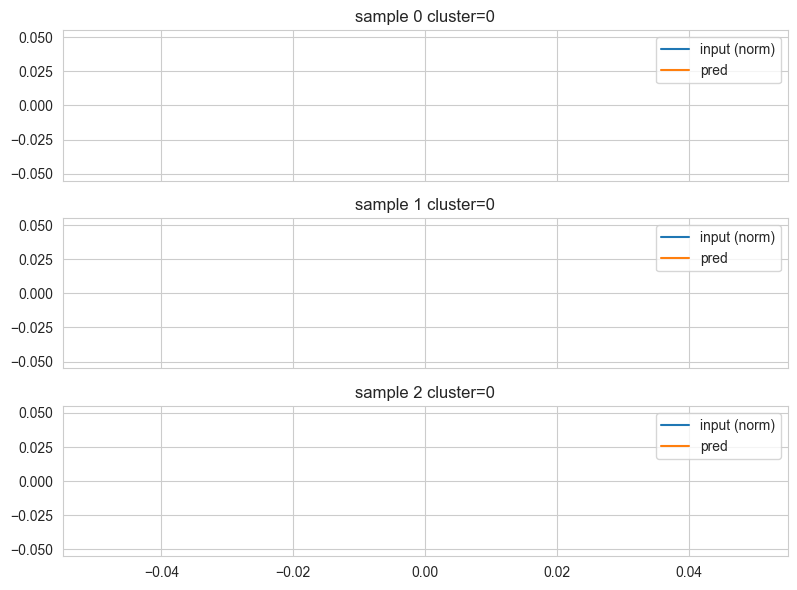

In [19]:
# Section 9: map clusters back to model outputs and plot example windows per cluster
def plot_cluster_examples(cluster_id, labels, n=5):
    idx = np.where(labels == cluster_id)[0]
    if idx.size == 0:
        print('No samples for cluster', cluster_id)
        return
    sel = idx[:n]
    fig, axes = plt.subplots(len(sel), 1, figsize=(8, 2*len(sel)), sharex=True)
    if len(sel) == 1:
        axes = [axes]
    for ax, i in zip(axes, sel):
        # input window if available
        label = f'sample {i}'
        if 'windows' in globals() and i < windows.shape[0]:
            inp = windows[i]
            ax.plot(np.arange(len(inp)), inp, label='input (norm)')
        # predictions if available
        if preds is not None:
            p = np.asarray(preds)
            # preds may be [N, T, C] or [N, T]
            if p.ndim == 3:
                p0 = p[i, :, 0]
            elif p.ndim == 2:
                p0 = p[i]
            else:
                p0 = p
            ax.plot(np.arange(len(inp), len(inp) + len(p0)), p0, label='pred')
        ax.legend(loc='upper right')
        ax.set_title(label + f' cluster={cluster_id}')
    fig.tight_layout()
    fname = os.path.join(FIG_DIR, f'cluster_{chosen_k}_{cluster_id}_examples.png')
    fig.savefig(fname)
    print('Saved', fname)

# plot examples for each cluster
for cid in np.unique(labels):
    plot_cluster_examples(cid, labels, n=3)

In [20]:
# Section 10: cluster evaluation and diagnostics
print('cluster sizes:')
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(u, c)
if emb_pca.shape[0] > 1 and len(np.unique(labels)) > 1:
    try:
        sil = silhouette_score(emb_pca, labels)
        db = davies_bouldin_score(emb_pca, labels)
        print('silhouette=', sil, 'davies-bouldin=', db)
    except Exception as e:
        print('Evaluation failed:', e)

# save assignments
df_out = pd.DataFrame({'sample_index': np.arange(len(labels)), 'cluster': labels})
df_out.to_csv(os.path.join(OUT_DIR, f'cluster_assignments_k{chosen_k}.csv'), index=False)
print('Saved cluster_assignments CSV')

cluster sizes:
0 2290
Saved cluster_assignments CSV


In [21]:
# Section 11: per-cluster HRV feature summaries (if HRV features present)
# This cell computes mean HRV features per cluster and saves a CSV for inspection.
try:
    hrv_feats, hrv_names = load_hrv_features(OUT_DIR)
    if hrv_feats is None:
        # maybe embeddings contain HRV appended (embeddings_with_hrv)
        emb_combined_path = os.path.join(OUT_DIR, 'embeddings_with_hrv.npy')
        if os.path.exists(emb_combined_path):
            emb_combined = np.load(emb_combined_path, allow_pickle=True)
            # assume last 7 columns are HRV features (as produced by compute_and_combine_hrv.py)
            hrv_feats = emb_combined[:, -7:]
            hrv_names = ['mean', 'median', 'min', 'max', 'rmssd', 'sdnn', 'pnn50']
            print('Extracted HRV features from embeddings_with_hrv.npy')

    if hrv_feats is None:
        print('No HRV features found in outputs/. Skipping per-cluster HRV summaries.')
    else:
        # ensure shapes align with labels
        hrv_feats = np.asarray(hrv_feats, dtype=float)
        n_samples = min(hrv_feats.shape[0], len(labels))
        if hrv_feats.shape[0] != len(labels):
            print(f'Warning: HRV feature count ({hrv_feats.shape[0]}) != samples ({len(labels)}). Aligning by taking first {n_samples} samples.')
        hrv_trim = hrv_feats[:n_samples]
        labels_trim = np.asarray(labels)[:n_samples]

        import pandas as pd
        rows = []
        for cid in np.unique(labels_trim):
            idx = np.where(labels_trim == cid)[0]
            if idx.size == 0:
                continue
            vals = hrv_trim[idx]
            mean_vals = np.nanmean(vals, axis=0)
            row = {'cluster': int(cid), 'n_samples': int(idx.size)}
            for name, v in zip(hrv_names, mean_vals):
                row[f'mean_{name}'] = float(v)
            rows.append(row)
        if rows:
            df_summary = pd.DataFrame(rows)
            out_csv = os.path.join(OUT_DIR, f'cluster_hrv_summary_k{chosen_k}.csv')
            df_summary.to_csv(out_csv, index=False)
            print('Saved per-cluster HRV summary to', out_csv)
        else:
            print('No clusters with samples found to summarize HRV features.')
except Exception as e:
    print('Per-cluster HRV summary failed:', e)


Saved per-cluster HRV summary to outputs/cluster_hrv_summary_k2.csv


/var/folders/js/0r3rgb8104s7jnth94r86nd00000gn/T/ipykernel_54885/481729295.py:33: RuntimeWarning: Mean of empty slice
  mean_vals = np.nanmean(vals, axis=0)


## Next steps and reproducibility
- If you have only a handful of embeddings, run `TSFM.py` over the full dataset (loop over `ds` or DataLoader) to produce embeddings for all windows before clustering.
- Consider extracting standard HRV features (RMSSD, SDNN, LF/HF) and concatenating them with the model embeddings for more interpretable clusters.
- Try density-based clustering (HDBSCAN) to let the data decide cluster counts, and UMAP for visualization.
- Record the exact parameters (lookback/horizon, normalization) used by `TSFM.py` and save them together with `cluster_assignments_k{chosen_k}.csv` for reproducibility.